## Case Study: PDE Constrained Optimization

One type of simulation-based optimization problems involve optimization problems with governing equations obtained from partial differential equations.

As an introduction to this subject, we'll examine Poisson's equation for $u$ such that

\begin{equation*}
- \nabla^2 u = g \qquad \qquad \text{in} \; \Omega
\end{equation*}

where $g$ is the right-hand-side with the boundary conditions

\begin{equation*}
u = u_{0} \qquad \qquad \text{on} \; \partial \Omega
\end{equation*}

Consider the case where we would like to compute the approximate maximum value for $u$. A smooth approximation of this value is to select a $p$ and compute the function

\begin{equation*}
f(x, u) = \dfrac{1}{p} \ln \left( \int_{\Omega} e^{p u} \, d\Omega \right) \approx \max_{\Omega} u
\end{equation*}

### The continuous adjoint

We could obtain the adjoint equations as we have before, by first discretizing the Poisson equation and then using the adjoint method we've derived before. This method is called the discrete adjoint method, since it is based on the discretized version of the equations.
Instead, we can pursue the continuous adjoint, based on the PDE itself.

The PDE for the adjoint equations can be derived using the Lagrangian that combines the function of interest with the inner product of the adjoint variable $\psi$ with the strong form of the governing equations

\begin{equation*}
\mathcal{L} = \dfrac{1}{p} \ln \left( \int_{\Omega} e^{p u} \, d\Omega \right) - 
\int_{\Omega} \psi ( \nabla^{2} u + g) \, d\Omega
\end{equation*}

Now, recall that we derived the discrete adjoint equations by taking the derivative of the Lagrangian with respect to the state variables. Here, a regular derivative is not possible, so instead consider how the Lagrangian with vary as the solution $u$ changes a small amount $\delta u$. This small change will respect the boundary conditions such that $\delta u = 0$ on $\partial \Omega$.

A small change in the $\delta u$ leads to a change in the Laplacian $\delta \mathcal{L}$ as follows

\begin{equation*}
\delta \mathcal{L} = \dfrac{\int_{\Omega} \delta u e^{p u} \, d\Omega}{\int_{\Omega} e^{p u} \, d\Omega} -
\int_{\Omega} \psi \nabla^{2} \delta u \, d\Omega
\end{equation*}

Next, we can apply integration by parts to obtain the following expression

\begin{equation*}
\int_{\Omega} \psi \nabla^{2} \delta u \, d\Omega = \int_{\Omega} \nabla \cdot (\psi \nabla \delta u ) - \nabla \psi \cdot \nabla \delta u \, d\Omega = \int_{\partial \Omega} \psi \nabla \delta u \, dS - \int_{\Omega} \nabla \psi \cdot \nabla \delta u \, d\Omega
\end{equation*}

We can again apply integration by parts to the second term to obtain the following

\begin{equation*}
\int_{\Omega} \nabla \psi \cdot \nabla \delta u \, d\Omega = \int_{\Omega} \nabla \cdot ( \delta u \nabla \psi)  - \delta u \nabla^{2} \psi  \, d\Omega = \int_{\partial \Omega} \delta u \nabla \psi \, dS - \int_{\Omega} \delta u \nabla^{2} \psi  \, d\Omega
\end{equation*}

Combining these together, we get the relationship

\begin{equation*}
\int_{\Omega} \psi \nabla^{2} \delta u \, d\Omega = \int_{\partial \Omega} \psi \nabla \delta u \, dS - \int_{\partial \Omega} \delta u \nabla \psi \, dS + \int_{\Omega} \delta u \nabla^{2} \psi  \, d\Omega
\end{equation*}

Applying this relationship back to the Lagrangian gives the following the expression for $\delta \mathcal{L}$

\begin{equation*}
\delta \mathcal{L} = \dfrac{\int_{\Omega} \delta u e^{p u} \, d\Omega}{\int_{\Omega} e^{p u} \, d\Omega} - \int_{\partial \Omega} \psi \nabla \delta u \, dS + \int_{\partial \Omega} \delta u \nabla \psi \, dS - \int_{\Omega} \delta u \nabla^{2} \psi  \, d\Omega
\end{equation*}

To eliminate the boundary terms, we note that $\delta u = 0$ on $\partial \Omega$ and impose $\psi = 0$ on $\partial \Omega$.

Combining the final results

\begin{equation*}
\delta \mathcal{L} = \int_{\Omega} \delta u \left(- \nabla^{2} \psi + \dfrac{e^{p u}}{\int_{\Omega} e^{p u} \, d\Omega} \right) \, d\Omega = 0
\end{equation*}

As a result, the governing equation for the adjoint variable is

\begin{equation*}
- \nabla^{2} \psi  = - \dfrac{e^{p u}}{\int_{\Omega} e^{p u} \, d\Omega}
\end{equation*}

with the boundary conditions $\psi = 0$ on $\partial \Omega$.

### The discrete adjoint

In this case, we can discretize the problem using the finite-element method to obtain the residuals in the form

\begin{equation*}
R(x, u) = K(x) u - g = 0
\end{equation*}

Here $K(x)$ is a symmetric system of equations and $g$ is a discretized version of the right-hand-side of the Poisson equation.

### Dual consistency

Dual consistency occurs when the discrete adjoint is consistent with a discretization of the continuous adjoint. This is generally guaranteed if you discretize your system with a Galerkin method, such as the finite-element method.


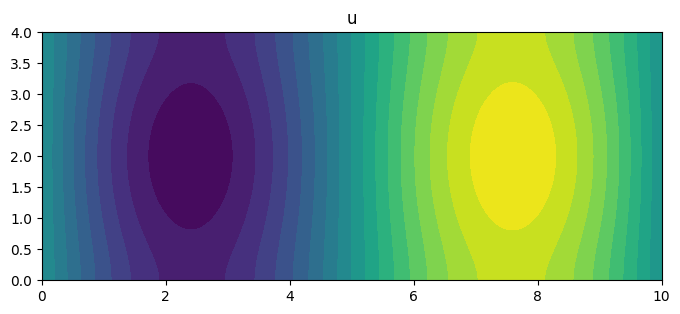

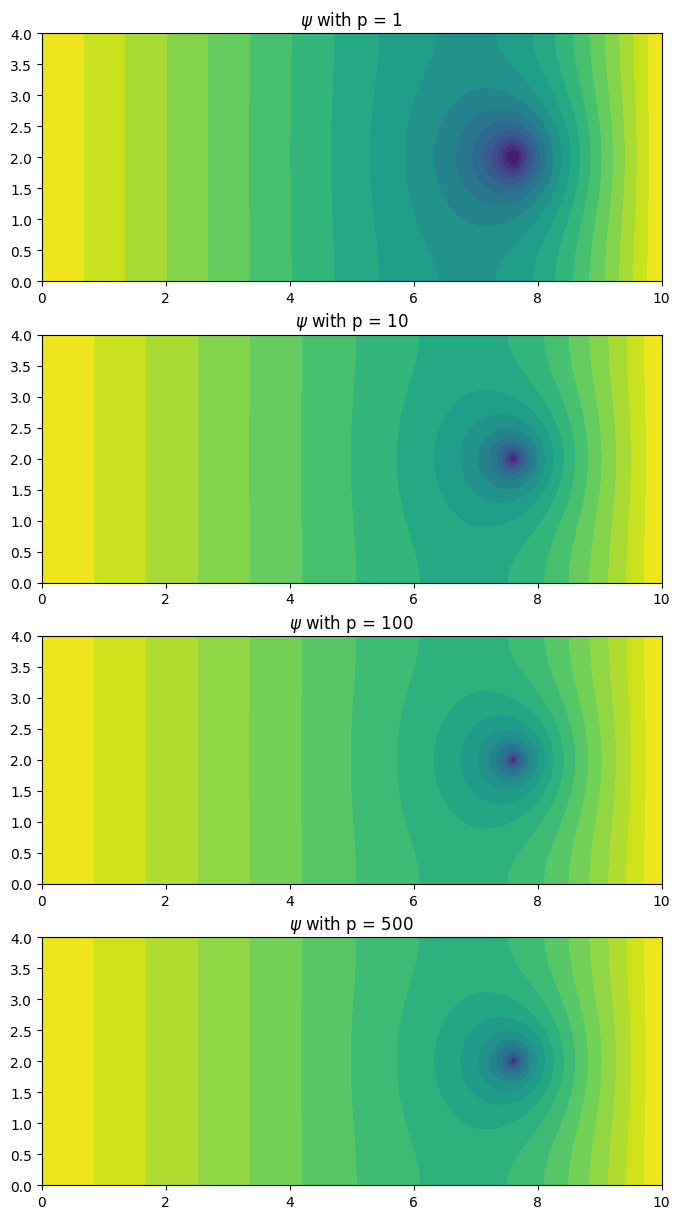

In [3]:
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve
import matplotlib.pylab as plt
import matplotlib.tri as tri

class Poisson:
    def __init__(self, conn, x, bcs, gfunc):
        self.conn = np.array(conn)
        self.x = np.array(x)

        self.nelems = self.conn.shape[0]
        self.nnodes = int(np.max(self.conn)) + 1
        self.nvars = self.nnodes

        self.reduced = self._compute_reduced_variables(self.nvars, bcs)
        self.g = self._compute_rhs(gfunc)
        
        # Set up arrays for assembling the matrix
        i = []
        j = []
        for index in range(self.nelems):
            for ii in self.conn[index, :]:
                for jj in self.conn[index, :]:
                    i.append(ii)
                    j.append(jj)

        # Convert the lists into numpy arrays
        self.i = np.array(i, dtype=int)
        self.j = np.array(j, dtype=int)

    def _compute_reduced_variables(self, nvars, bcs):
        """
        Compute the reduced set of variables
        """
        reduced = list(range(nvars))
        for node in bcs:
            reduced.remove(node)
            
        return reduced

    def _eval_basis_and_jacobian(self, xi, eta, xe, ye, J, detJ, invJ=None):
        """
        Evaluate the basis functions and Jacobian of the transformation
        """

        N = 0.25*np.array([(1.0 - xi)*(1.0 - eta),
                            (1.0 + xi)*(1.0 - eta),
                            (1.0 + xi)*(1.0 + eta),
                            (1.0 - xi)*(1.0 + eta)])
        Nxi = 0.25*np.array([-(1.0 - eta), (1.0 - eta), (1.0 + eta), -(1.0 + eta)])
        Neta = 0.25*np.array([-(1.0 - xi), -(1.0 + xi), (1.0 + xi), (1.0 - xi)])

        # Compute the Jacobian transformation at each quadrature points
        J[:, 0, 0] = np.dot(xe, Nxi)
        J[:, 1, 0] = np.dot(ye, Nxi)
        J[:, 0, 1] = np.dot(xe, Neta)
        J[:, 1, 1] = np.dot(ye, Neta)

        # Compute the inverse of the Jacobian
        detJ[:] = J[:, 0, 0]*J[:, 1, 1] - J[:, 0, 1]*J[:, 1, 0]

        if invJ is not None:
            invJ[:, 0, 0] = J[:, 1, 1]/detJ
            invJ[:, 0, 1] = -J[:, 0, 1]/detJ
            invJ[:, 1, 0] = -J[:, 1, 0]/detJ
            invJ[:, 1, 1] = J[:, 0, 0]/detJ

        return N, Nxi, Neta

    def _compute_rhs(self, gfunc):
        """
        Compute the right-hand-side using the function callback
        """
        
        forces = np.zeros(self.nnodes)
        
        # Compute the element stiffness matrix
        gauss_pts = [-1.0/np.sqrt(3.0), 1.0/np.sqrt(3.0)]

        J = np.zeros((self.nelems, 2, 2))
        detJ = np.zeros(self.nelems)

        # Compute the x and y coordinates of each element
        xe = self.x[self.conn, 0]
        ye = self.x[self.conn, 1]
        
        fe = np.zeros(self.conn.shape)

        for j in range(2):
            for i in range(2):
                xi = gauss_pts[i]
                eta = gauss_pts[j]
                N, Nxi, Neta = self._eval_basis_and_jacobian(xi, eta, xe, ye, J, detJ)
                
                # Evaluate the function
                xvals = np.dot(xe, N)
                yvals = np.dot(ye, N)
                gvals = gfunc(xvals, yvals)

                fe += np.outer(detJ * gvals, N)
        
        for i in range(4):
            np.add.at(forces, self.conn[:, i], fe[:, i])
                
        return forces

    def assemble_jacobian(self):
        """
        Assemble the Jacobian matrix
        """

        # Compute the element stiffness matrix
        gauss_pts = [-1.0/np.sqrt(3.0), 1.0/np.sqrt(3.0)]

        # Assemble all of the the 4 x 4 element stiffness matrix
        Ke = np.zeros((self.nelems, 4, 4))
        Be = np.zeros((self.nelems, 2, 4))

        J = np.zeros((self.nelems, 2, 2))
        invJ = np.zeros(J.shape)
        detJ = np.zeros(self.nelems)

        # Compute the x and y coordinates of each element
        xe = self.x[self.conn, 0]
        ye = self.x[self.conn, 1]

        for j in range(2):
            for i in range(2):
                xi = gauss_pts[i]
                eta = gauss_pts[j]
                N, Nxi, Neta = self._eval_basis_and_jacobian(xi, eta, xe, ye, J, detJ, invJ)

                # Compute the derivative of the shape functions w.r.t. xi and eta
                # [Nx, Ny] = [Nxi, Neta]*invJ
                Nx = np.outer(invJ[:, 0, 0], Nxi) + np.outer(invJ[:, 1, 0], Neta)
                Ny = np.outer(invJ[:, 0, 1], Nxi) + np.outer(invJ[:, 1, 1], Neta)

                # Set the B matrix for each element
                Be[:, 0, :] = Nx
                Be[:, 1, :] = Ny

                # This is a fancy (and fast) way to compute the element matrices
                Ke += np.einsum('n,nij,nil -> njl', detJ, Be, Be)

        K = sparse.coo_matrix((Ke.flatten(), (self.i, self.j)))
        K = K.tocsr()

        return K

    def eval_ks(self, pval, u):
        
        # Compute the offset
        offset = np.max(u)
        
        # Compute the element stiffness matrix
        gauss_pts = [-1.0/np.sqrt(3.0), 1.0/np.sqrt(3.0)]

        # Assemble all of the the 4 x 4 element stiffness matrix
        Ke = np.zeros((self.nelems, 4, 4))
        Be = np.zeros((self.nelems, 2, 4))

        J = np.zeros((self.nelems, 2, 2))
        detJ = np.zeros(self.nelems)

        # Compute the x and y coordinates of each element
        xe = self.x[self.conn, 0]
        ye = self.x[self.conn, 1]
        
        # Compute the values of u for each element
        ue = u[self.conn]

        expsum = 0.0
        for j in range(2):
            for i in range(2):
                xi = gauss_pts[i]
                eta = gauss_pts[j]
                N, Nxi, Neta = self._eval_basis_and_jacobian(xi, eta, xe, ye, J, detJ)
                
                # Compute the values at the nodes
                uvals = np.dot(ue, N)

                expsum += np.sum(detJ * np.exp(pval*(uvals - offset)))
        
        return offset + np.log(expsum)/pval
    
    def eval_ks_adjoint_rhs(self, pval, u):
        
        # Compute the offset
        offset = np.max(u)
        
        # Compute the element stiffness matrix
        gauss_pts = [-1.0/np.sqrt(3.0), 1.0/np.sqrt(3.0)]

        # Assemble all of the the 4 x 4 element stiffness matrix
        Ke = np.zeros((self.nelems, 4, 4))
        Be = np.zeros((self.nelems, 2, 4))

        J = np.zeros((self.nelems, 2, 2))
        detJ = np.zeros(self.nelems)

        # Compute the x and y coordinates of each element
        xe = self.x[self.conn, 0]
        ye = self.x[self.conn, 1]
        
        # Compute the values of u for each element
        ue = u[self.conn]

        expsum = 0.0
        for j in range(2):
            for i in range(2):
                xi = gauss_pts[i]
                eta = gauss_pts[j]
                N, Nxi, Neta = self._eval_basis_and_jacobian(xi, eta, xe, ye, J, detJ)
                
                # Compute the values at the nodes
                uvals = np.dot(ue, N)

                expsum += np.sum(detJ * np.exp(pval*(uvals - offset)))
                
        # Store the element-wise right-hand-side
        erhs = np.zeros(self.conn.shape)
        
        for j in range(2):
            for i in range(2):
                xi = gauss_pts[i]
                eta = gauss_pts[j]
                N, Nxi, Neta = self._eval_basis_and_jacobian(xi, eta, xe, ye, J, detJ)
                
                # Compute the values at the nodes
                uvals = np.dot(ue, N)

                erhs += np.outer(detJ * np.exp(pval*(uvals - offset))/expsum, N)
        
        # Convert to the right-hand-side
        rhs = np.zeros(self.nnodes)
        for i in range(4):
            np.add.at(rhs, self.conn[:, i], erhs[:, i])
        
        return rhs
    
    def reduce_vector(self, forces):
        """
        Eliminate essential boundary conditions from the vector
        """
        return forces[self.reduced]

    def reduce_matrix(self, matrix):
        """
        Eliminate essential boundary conditions from the matrix
        """
        temp = matrix[self.reduced, :]
        return temp[:, self.reduced]

    def solve(self):
        """
        Perform a linear static analysis
        """

        K = self.assemble_jacobian()
        Kr = self.reduce_matrix(K)
        fr = self.reduce_vector(self.g)

        ur = sparse.linalg.spsolve(Kr, fr)

        u = np.zeros(self.nvars)
        u[self.reduced] = ur

        return u
    
    def solve_adjoint(self, pval):
        
        K = self.assemble_jacobian()
        Kr = self.reduce_matrix(K)
        fr = self.reduce_vector(self.g)

        ur = sparse.linalg.spsolve(Kr, fr)

        u = np.zeros(self.nvars)
        u[self.reduced] = ur
        
        max_val = self.eval_ks(pval, u)
        rhs = self.eval_ks_adjoint_rhs(pval, u)
        rhsr = self.reduce_vector(rhs)
        
        # Solve K * psi = - df/du^{T}
        psir = sparse.linalg.spsolve(Kr, -rhsr)

        psi = np.zeros(self.nvars)
        psi[self.reduced] = psir
        
        return psi

    def plot(self, u, ax=None, **kwargs):
        """
        Create a plot
        """

        # Create the triangles
        triangles = np.zeros((2*self.nelems, 3), dtype=int)
        triangles[:self.nelems, 0] = self.conn[:, 0]
        triangles[:self.nelems, 1] = self.conn[:, 1]
        triangles[:self.nelems, 2] = self.conn[:, 2]

        triangles[self.nelems:, 0] = self.conn[:, 0]
        triangles[self.nelems:, 1] = self.conn[:, 2]
        triangles[self.nelems:, 2] = self.conn[:, 3]

        # Create the triangulation object
        tri_obj = tri.Triangulation(self.x[:,0], self.x[:,1], triangles)

        if ax is None:
            fig, ax = plt.subplots()

        # Set the aspect ratio equal
        ax.set_aspect('equal')

        # Create the contour plot
        ax.tricontourf(tri_obj, u, **kwargs)

        return

m = 200
n = 50
nelems = m*n
nnodes = (m + 1)*(n + 1)
y = np.linspace(0, 4, n + 1)
x = np.linspace(0, 10, m + 1)
nodes = np.arange(0, (n + 1)*(m + 1)).reshape((n + 1, m + 1))

# Set the node locations
X = np.zeros((nnodes, 2))
for j in range(n + 1):
    for i in range(m + 1):
        X[i + j*(m + 1), 0] = x[i]
        X[i + j*(m + 1), 1] = y[j]

# Set the connectivity
conn = np.zeros((nelems, 4), dtype=int)
for j in range(n):
    for i in range(m):
        conn[i + j*m, 0] = nodes[j, i]
        conn[i + j*m, 1] = nodes[j, i + 1]
        conn[i + j*m, 2] = nodes[j + 1, i + 1]
        conn[i + j*m, 3] = nodes[j + 1, i]

# Set the constrained degrees of freedom at each node
bcs = []
for j in range(n):
    bcs.append(nodes[j, 0])
    bcs.append(nodes[j, -1])
    
def gfunc(xvals, yvals):
    return xvals * (xvals - 5.0) * (xvals - 10.0) * yvals * (yvals - 4.0)
    
# Create the Poisson problem
poisson = Poisson(conn, X, bcs, gfunc)

# Solve for the displacements
u = poisson.solve()

# Plot the u and the v displacements
fig, ax = plt.subplots(figsize=(8, 4))
poisson.plot(u, ax=ax, levels=20)
ax.set_title('u')

fig, ax = plt.subplots(4, 1, figsize=(8, 15))
for index, pval in enumerate([1, 10, 100, 500]):
    psi = poisson.solve_adjoint(pval)
    poisson.plot(psi, ax=ax[index], levels=20)
    ax[index].set_title(r'$\psi$ with p = %g'%(pval))

plt.show()

### Nonlinear PDE-constrained optimization

The goal of this problem is to minimize the approximate maximum value of the function

\begin{equation*}
- \nabla \cdot \left( h(x) (1 + u^{2}) \nabla u \right) = g
\end{equation*}

with the boundary conditions $u = u_{0}$ on $\partial \Omega$.

Here $g$ will be a specified function, while $h(x)$ will be a function generated from a linear combination of functions of the form

\begin{equation*}
h(x) = \sum_{k=1}^{n} x_{k} h_{k}
\end{equation*}

where each $h_{k} \ge 0$ is specified.

### Finite element equations

Note that this is section is for reference only and is material covered in a finite element course.

The finite-element governing equations for this problem can be derived by first finding the nonlinear variational form for the governing equaitons.
A nonlinear variational form, in general, imposes the condition that

\begin{equation*}
F(u, v) = 0 \qquad \forall v \in \mathcal{V}
\end{equation*}

where $u$ is the solution and $v \in \mathcal{V}$ is a test function satisfying the boundary conditions, $v = 0$ on $\partial \Omega$.

For the nonlinear problem, $F(u, v)$ takes the form

\begin{equation*}
F(u, v) = -\int_{\Omega} v \left( \nabla \cdot \left( h(x) (1 + u^{2}) \nabla u \right) + g \right) \, d\Omega 
\end{equation*}

This can be reformulated using integration by parts so that

\begin{equation*}
\begin{aligned}
\int_{\Omega} v \left( \nabla \cdot \left( h(x) (1 + u^{2}) \nabla u \right) \right) \, d\Omega 
&= \int_{\Omega} \nabla \cdot \left( v h(x) \left( (1 + u^{2}) \nabla u \right) \right) - h(x) (1 + u^{2}) \nabla u \cdot \nabla v d\Omega \\ 
&= \int_{\partial \Omega} v \left( h(x) (1 + u^{2}) \nabla u \right) dS - \int_{\Omega} h(x) (1 + u^{2}) \nabla u \cdot \nabla v d\Omega \\
\end{aligned}
\end{equation*}

With this definition, and applying the condition $v = 0$ on $\partial \Omega$, the nonlinear variational form is

\begin{equation*}
F(u, v) = \int_{\Omega} h(x) (1 + u^{2}) \nabla u \cdot \nabla v - g(x) v \, d\Omega = 0 \qquad \forall v \in \mathcal{V}
\end{equation*}

The finite-element discretization consists of picking a finite function space $\mathcal{V}_{h} \subset \mathcal{V}$ with the solution and test functions $u_{h}, v_{h} \in \mathcal{V}_{h}$ and enforcing the criteria that

\begin{equation*}
F(u_{h}, v_{h}) = \int_{\Omega} h(x) (1 + u_{h}^{2}) \nabla u_{h} \cdot \nabla v_{h} - g(x) v_{h} \, d\Omega = 0 \qquad \forall v_{h} \in \mathcal{V}_{h}
\end{equation*}

The finite element governing equations can be derived by writing the trial and test functions in terms of the element shape functions $N$, giving the relationships $u_{h} = N \mathbf{u}$ and $v_{h} = N \mathbf{v}$ and their derivatives $\nabla u_{h} = B \mathbf{u}$ and $\nabla v_{h} = B \mathbf{v}$, where $\mathbf{u}, \mathbf{v} \in \mathbb{R}^{n_{dof}}$.

The weak form of the equations can now be written as

\begin{equation*}
\begin{aligned}
F(u_{h}, v_{h}) &= \int_{\Omega} h(x) (1 + u_{h}^{2}) \mathbf{u}^{T} B^{T} B \mathbf{v} - g(x) N \mathbf{v} \, d\Omega = 0 \\
&= \left[ \int_{\Omega} h(x) (1 + u_{h}^{2}) \mathbf{u}^{T} B^{T} B  - g(x) N \, d\Omega \right] \mathbf{v} = 0 \qquad \forall \mathbf{v} \in \mathbb{R}^{n_{dof}} \\
\end{aligned}
\end{equation*}

The residuals can now be identified as

\begin{equation*}
R(x, \mathbf{u}) = \int_{\Omega} h(x) (1 + u_{h}^{2})  B^{T} B \mathbf{u}  - g(x) N^{T} \, d\Omega = 0
\end{equation*}


### Optimization problem

In this problem, you will solve the following optimization problem

\begin{equation*}
\begin{aligned}
\min_{x} \qquad & - \left[ \frac{1}{p} \ln \int_{\Omega} e^{p u} \, d\Omega \right] \\
\text{such that} \qquad & -0.9 \le x_{i} \le 1 \\
& \sum_{i=1}^{n} x_{i}^2 = 4 \\
\text{governed by} \qquad & F(u, v) = 0 \\
\end{aligned}
\end{equation*}

Note that you are minimizing the negative of the approximate maximum value. This is equivalent to maximizing the approximate maximum value.

In this problem, you will solve the problem on the unit square $\xi \in [0, 1]^{2}$ with the boundary conditions $u_{0} = 0$.
The right-hand-side is

\begin{equation*}
g = 10^{4} \xi_1 (1 - \xi_1)(1 - 2\xi_{1})\xi_2 (1 - \xi_2)(1 - 2\xi_{2})
\end{equation*}

The function $h(x)$ is given by

\begin{equation*}
\begin{aligned}
b_{k}(\xi_{1}) &= \binom{n-1}{k-1} (1 - \xi_1)^{n-1-k} \xi_{1}^{k-1} \qquad k = 1, \ldots, n\\
h(x) &= 1 + \sum_{k=1}^{n} x_{k} \left[4 \xi_2 (1 - \xi_2) b_{k}(\xi_{1}) \right] \\
\end{aligned}
\end{equation*}

For this problem you must:

1. Derive the continuous adjoint using an analogous approach as presented in the nodes for the linear Poisson problem.
2. Derive and implement the adjoint method for the problem. Test your implementation against the complex step method. 
3. Solve the optimization problem using `scipy.minimize`


Iter  Norm                     
    0     6.341311296122908e-01
    1     2.053534548860870e+00
    2     5.484490071748321e-01
    3     1.008902863355295e-01
    4     5.743546950344437e-03
    5     1.932874507196310e-05
    6     1.802514099340312e-10
    7     1.007095292172337e-14


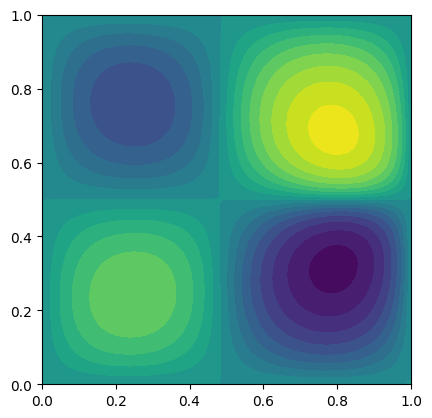

In [2]:
import numpy as np
from scipy import sparse
from scipy import special
from scipy.sparse.linalg import spsolve
import matplotlib.pylab as plt
import matplotlib.tri as tri
from scipy.optimize import minimize
from scipy.optimize import LinearConstraint, NonlinearConstraint

class PoissonProblem:
    def __init__(self, N):
        self.N = min(10, max(N, 2))

    def gfunc(self, xvals, yvals):
        """
        Given the x and y locations return the right-hand-side
        """
        g = 1e4 * xvals*(1.0 - xvals)*(1.0 - 2.0*xvals)*yvals*(1.0 - yvals)*(1.0 - 2.0*yvals)

        return g

    def hfunc(self, xdv, xvals, yvals):
        """
        Given the design variables and the x and y locations return h
        """

        h = np.ones(xvals.shape, dtype=xdv.dtype)
        for k in range(self.N):
            coef = special.binom(self.N - 1, k)
            xarg = coef * (1.0 - xvals)**(self.N - 1 - k) * xvals**k
            yarg = 4.0 * yvals * (1.0 - yvals)
            h += xdv[k] * xarg * yarg

        if np.min(h) < 0.0:
            print(np.min(h))
            print(xdv)
        return h

    def add_hfunc_deriv(self, xvals, yvals, dfdh, dfdx):
        """
        Add the contributions to the derivative
        """

        for k in range(self.N):
            coef = special.binom(self.N - 1, k)
            xarg = coef * (1.0 - xvals)**(self.N - 1 - k) * xvals**k
            yarg = 4.0 * yvals * (1.0 - yvals)
            dfdx[k] += np.dot(dfdh, xarg * yarg)

        return

class NonlinearPoisson:
    def __init__(self, conn, x, bcs, problem):
        """
        Initialize the nonlinear Poisson problem

        - grad . (h(x)(1.0 + u^2) grad(u))) = g

        Args:
            conn: The connectivity
            x: The node locations
            bcs: The boundary conditions
            problem: The Poisson problem instance
        """

        self.conn = np.array(conn)
        self.x = np.array(x)
        self.problem = problem
        self.u_save = None

        self.nelems = self.conn.shape[0]
        self.nnodes = int(np.max(self.conn)) + 1
        self.nvars = self.nnodes

        self.reduced = self._compute_reduced_variables(self.nvars, bcs)

        # Set up arrays for assembling the matrix
        i = []
        j = []
        for index in range(self.nelems):
            for ii in self.conn[index, :]:
                for jj in self.conn[index, :]:
                    i.append(ii)
                    j.append(jj)

        # Convert the lists into numpy arrays
        self.i = np.array(i, dtype=int)
        self.j = np.array(j, dtype=int)

    def _compute_reduced_variables(self, nvars, bcs):
        """
        Compute the reduced set of variables
        """
        reduced = list(range(nvars))
        for node in bcs:
            reduced.remove(node)

        return reduced

    def _eval_basis_and_jacobian(self, xi, eta, xe, ye, J, detJ, invJ=None):
        """
        Evaluate the basis functions and Jacobian of the transformation
        """

        N = 0.25*np.array([(1.0 - xi)*(1.0 - eta),
                            (1.0 + xi)*(1.0 - eta),
                            (1.0 + xi)*(1.0 + eta),
                            (1.0 - xi)*(1.0 + eta)])
        Nxi = 0.25*np.array([-(1.0 - eta), (1.0 - eta), (1.0 + eta), -(1.0 + eta)])
        Neta = 0.25*np.array([-(1.0 - xi), -(1.0 + xi), (1.0 + xi), (1.0 - xi)])

        # Compute the Jacobian transformation at each quadrature points
        J[:, 0, 0] = np.dot(xe, Nxi)
        J[:, 1, 0] = np.dot(ye, Nxi)
        J[:, 0, 1] = np.dot(xe, Neta)
        J[:, 1, 1] = np.dot(ye, Neta)

        # Compute the inverse of the Jacobian
        detJ[:] = J[:, 0, 0]*J[:, 1, 1] - J[:, 0, 1]*J[:, 1, 0]

        if invJ is not None:
            invJ[:, 0, 0] = J[:, 1, 1]/detJ
            invJ[:, 0, 1] = -J[:, 0, 1]/detJ
            invJ[:, 1, 0] = -J[:, 1, 0]/detJ
            invJ[:, 1, 1] = J[:, 0, 0]/detJ

        return N, Nxi, Neta

    def assemble_residual(self, xdv, u):
        """
        Assemble the residuals

        Args:
            xdv: The design variable values
            u: The state variable values

        Returns:
            res: The residuals of the governing equations
        """

        # Check what type to use
        dtype = float
        if np.iscomplexobj(xdv) or np.iscomplexobj(u):
            dtype = complex

        # Gauss points
        gauss_pts = [-1.0/np.sqrt(3.0), 1.0/np.sqrt(3.0)]

        # The residuals for each finite-element
        Re = np.zeros((self.nelems, 4), dtype=dtype)

        # Data for each finite-element
        Be = np.zeros((self.nelems, 2, 4))

        detJ = np.zeros(self.nelems)
        J = np.zeros((self.nelems, 2, 2))
        invJ = np.zeros(J.shape)

        # Compute the x and y coordinates of each element
        xe = self.x[self.conn, 0]
        ye = self.x[self.conn, 1]

        # Set the state variable for all the elements
        ue = u[self.conn]

        for j in range(2):
            for i in range(2):
                xi = gauss_pts[i]
                eta = gauss_pts[j]
                N, Nxi, Neta = self._eval_basis_and_jacobian(xi, eta, xe, ye, J, detJ, invJ)

                # Compute the derivative of the shape functions w.r.t. xi and eta
                # [Nx, Ny] = [Nxi, Neta]*invJ
                Nx = np.outer(invJ[:, 0, 0], Nxi) + np.outer(invJ[:, 1, 0], Neta)
                Ny = np.outer(invJ[:, 0, 1], Nxi) + np.outer(invJ[:, 1, 1], Neta)

                # Set the B matrix for each element
                Be[:, 0, :] = Nx
                Be[:, 1, :] = Ny

                # Compute the u values at all the element locations
                uvals = np.dot(ue, N)

                # Evaluate the function
                xvals = np.dot(xe, N)
                yvals = np.dot(ye, N)
                g = self.problem.gfunc(xvals, yvals)
                h = self.problem.hfunc(xdv, xvals, yvals)

                # Add the contribution to the element residuals
                Re += np.einsum('n,nij,nil,nl -> nj', detJ * h * (1.0 + uvals**2), Be, Be, ue)
                Re -= np.outer(detJ * g, N)

        # Assemble the residuals
        res = np.zeros(self.nvars, dtype=u.dtype)
        for i in range(4):
            np.add.at(res, self.conn[:, i], Re[:, i])

        return res

    def assemble_jacobian(self, xdv, u):
        """
        Assemble the residual and Jacobian matrix

        Args:
            xdv: The design variable values
            u: The state variable values

        Returns:
            The Jacobian matrix
        """

        # Check what type to use
        dtype = float
        if np.iscomplexobj(xdv) or np.iscomplexobj(u):
            dtype = complex

        # Gauss points
        gauss_pts = [-1.0/np.sqrt(3.0), 1.0/np.sqrt(3.0)]

        # The residuals for each finite-element
        Re = np.zeros((self.nelems, 4), dtype=dtype)
        Ke = np.zeros((self.nelems, 4, 4), dtype=dtype)

        # Data for each finite-element
        Be = np.zeros((self.nelems, 2, 4))

        detJ = np.zeros(self.nelems)
        J = np.zeros((self.nelems, 2, 2))
        invJ = np.zeros(J.shape)

        # Compute the x and y coordinates of each element
        xe = self.x[self.conn, 0]
        ye = self.x[self.conn, 1]

        # Set the state variable for all the elements
        ue = u[self.conn]

        for j in range(2):
            for i in range(2):
                xi = gauss_pts[i]
                eta = gauss_pts[j]
                N, Nxi, Neta = self._eval_basis_and_jacobian(xi, eta, xe, ye, J, detJ, invJ)

                # Compute the derivative of the shape functions w.r.t. xi and eta
                # [Nx, Ny] = [Nxi, Neta]*invJ
                Nx = np.outer(invJ[:, 0, 0], Nxi) + np.outer(invJ[:, 1, 0], Neta)
                Ny = np.outer(invJ[:, 0, 1], Nxi) + np.outer(invJ[:, 1, 1], Neta)

                # Set the B matrix for each element
                Be[:, 0, :] = Nx
                Be[:, 1, :] = Ny

                # Compute the u values at all the element locations
                uvals = np.dot(ue, N)

                # Evaluate the function
                xvals = np.dot(xe, N)
                yvals = np.dot(ye, N)
                g = self.problem.gfunc(xvals, yvals)
                h = self.problem.hfunc(xdv, xvals, yvals)

                # Add the contributions to the residuals
                Re += np.einsum('n,nij,nil,nl -> nj', detJ * h * (1.0 + uvals**2), Be, Be, ue)
                Re -= np.outer(detJ * g, N)

                # This is a fancy (and fast) way to compute the element matrices
                Ke += np.einsum('n,nij,nil -> njl', detJ * h * (1.0 + uvals**2), Be, Be)
                Ke += np.einsum('n,nij,nil,nl,k -> njk', 2.0 * detJ * h * uvals, Be, Be, ue, N)

        # Assemble the residuals
        res = np.zeros(self.nvars, dtype=dtype)
        for i in range(4):
            np.add.at(res, self.conn[:, i], Re[:, i])

        # Assemble the Jacobian matrix
        K = sparse.coo_matrix((Ke.flatten(), (self.i, self.j)))
        K = K.tocsr()

        return res, K

    def adjoint_res_product(self, xdv, u, psi):
        """
        Compute the product of the adjoint variables with the derivative of the residuals
        """

        dfdx = np.zeros(self.problem.N, dtype=xdv.dtype)
        dfdh = np.zeros(self.nelems, dtype=xdv.dtype)

        # Gauss points
        gauss_pts = [-1.0/np.sqrt(3.0), 1.0/np.sqrt(3.0)]

        # Data for each finite-element
        detJ = np.zeros(self.nelems)
        J = np.zeros((self.nelems, 2, 2))
        invJ = np.zeros(J.shape)

        # Compute the point gradient from the
        Be = np.zeros((self.nelems, 2, 4))

        # Compute the x and y coordinates of each element
        xe = self.x[self.conn, 0]
        ye = self.x[self.conn, 1]

        # Set the state variable for all the elements
        ue = u[self.conn]
        psie = psi[self.conn]

        for j in range(2):
            for i in range(2):
                xi = gauss_pts[i]
                eta = gauss_pts[j]
                N, Nxi, Neta = self._eval_basis_and_jacobian(xi, eta, xe, ye, J, detJ, invJ)

                # Compute the derivative of the shape functions w.r.t. xi and eta
                # [Nx, Ny] = [Nxi, Neta]*invJ
                Nx = np.outer(invJ[:, 0, 0], Nxi) + np.outer(invJ[:, 1, 0], Neta)
                Ny = np.outer(invJ[:, 0, 1], Nxi) + np.outer(invJ[:, 1, 1], Neta)

                # Set the B matrix for each element
                Be[:, 0, :] = Nx
                Be[:, 1, :] = Ny

                # Compute the u values at all the element locations
                uvals = np.dot(ue, N)

                # Evaluate the function
                xvals = np.dot(xe, N)
                yvals = np.dot(ye, N)

                dfdh = np.einsum('n,nij,nj,nil,nl -> n', detJ * (1.0 + uvals**2), Be, psie, Be, ue)
                self.problem.add_hfunc_deriv(xvals, yvals, dfdh, dfdx)

        return dfdx

    def eval_ks(self, pval, u):

        # Compute the offset
        offset = np.max(u)

        # Compute the element stiffness matrix
        gauss_pts = [-1.0/np.sqrt(3.0), 1.0/np.sqrt(3.0)]

        # Assemble all of the the 4 x 4 element stiffness matrix
        Ke = np.zeros((self.nelems, 4, 4))
        Be = np.zeros((self.nelems, 2, 4))

        J = np.zeros((self.nelems, 2, 2))
        detJ = np.zeros(self.nelems)

        # Compute the x and y coordinates of each element
        xe = self.x[self.conn, 0]
        ye = self.x[self.conn, 1]

        # Compute the values of u for each element
        ue = u[self.conn]

        expsum = 0.0
        for j in range(2):
            for i in range(2):
                xi = gauss_pts[i]
                eta = gauss_pts[j]
                N, Nxi, Neta = self._eval_basis_and_jacobian(xi, eta, xe, ye, J, detJ)

                # Compute the values at the nodes
                uvals = np.dot(ue, N)

                expsum += np.sum(detJ * np.exp(pval*(uvals - offset)))

        return offset + np.log(expsum)/pval

    def eval_ks_adjoint_rhs(self, pval, u):

        # Compute the offset
        offset = np.max(u)

        # Compute the element stiffness matrix
        gauss_pts = [-1.0/np.sqrt(3.0), 1.0/np.sqrt(3.0)]

        # Information about the element transformation
        detJ = np.zeros(self.nelems)
        J = np.zeros((self.nelems, 2, 2))

        # Compute the x and y coordinates of each element
        xe = self.x[self.conn, 0]
        ye = self.x[self.conn, 1]

        # Compute the values of u for each element
        ue = u[self.conn]

        expsum = 0.0
        for j in range(2):
            for i in range(2):
                xi = gauss_pts[i]
                eta = gauss_pts[j]
                N, Nxi, Neta = self._eval_basis_and_jacobian(xi, eta, xe, ye, J, detJ)

                # Compute the values at the nodes
                uvals = np.dot(ue, N)

                expsum += np.sum(detJ * np.exp(pval*(uvals - offset)))

        # Store the element-wise right-hand-side
        erhs = np.zeros(self.conn.shape)

        for j in range(2):
            for i in range(2):
                xi = gauss_pts[i]
                eta = gauss_pts[j]
                N, Nxi, Neta = self._eval_basis_and_jacobian(xi, eta, xe, ye, J, detJ)

                # Compute the values at the nodes
                uvals = np.dot(ue, N)

                erhs += np.outer(detJ * np.exp(pval*(uvals - offset))/expsum, N)

        # Convert to the right-hand-side
        rhs = np.zeros(self.nnodes)
        for i in range(4):
            np.add.at(rhs, self.conn[:, i], erhs[:, i])

        return rhs

    def reduce_vector(self, forces):
        """
        Eliminate essential boundary conditions from the vector
        """
        return forces[self.reduced]

    def reduce_matrix(self, matrix):
        """
        Eliminate essential boundary conditions from the matrix
        """
        temp = matrix[self.reduced, :]
        return temp[:, self.reduced]

    def solve(self, xdv, u0=None, tol=1e-10, atol=1e-12, max_iter=10):
        """
        Perform a linear static analysis
        """

        dtype = float
        if np.iscomplexobj(xdv):
            dtype = complex
        elif u0 is not None and np.iscomplexobj(u0):
            dtype = complex

        if u0 is None:
            # Set the initial guess as u = 0
            u = np.zeros(self.nvars, dtype=dtype)
        else:
            u = u0

        res_norm_init = 0.0
        print('{0:5s} {1:25s}'.format('Iter', 'Norm'))

        for k in range(max_iter):
            res, K = self.assemble_jacobian(xdv, u)
            resr = self.reduce_vector(res)

            res_norm = np.sqrt(np.dot(resr, resr))
            print('{0:5d} {1:25.15e}'.format(k, res_norm))

            if k == 0:
                res_norm_init = res_norm
            elif res_norm < tol * res_norm_init or res_norm < atol:
                break

            Kr = self.reduce_matrix(K)
            updater = sparse.linalg.spsolve(Kr, resr)

            update = np.zeros(self.nvars, dtype=dtype)
            update[self.reduced] = updater

            u -= update

        return u

    def solve_adjoint(self, xdv, u, pval=10.0):
        """
        Compute the adjoint
        """

        res, K = self.assemble_jacobian(xdv, u)

        Kr = self.reduce_matrix(K)

        dfdu = self.eval_ks_adjoint_rhs(pval, u)
        dfdur = self.reduce_vector(dfdu)

        KrT = Kr.T
        psir = sparse.linalg.spsolve(KrT, -dfdur)

        psi = np.zeros(self.nvars)
        psi[self.reduced] = psir

        return psi

    def eval_total_derivative(self, xdv, u, pval=10.0):
        """
        Compute the total derivative using the adjoint method
        """
        psi = self.solve_adjoint(xdv, u)
        return self.adjoint_res_product(xdv, u, psi)

    def eval_objective(self, xdv, pval=10.0):
        """Evaluate the objective function"""
        self.u_save = self.solve(xdv, u0=self.u_save)
        return - self.eval_ks(pval, self.u_save)

    def eval_objective_gradient(self, xdv, pval=10.0):
        """Evaluate the objective function gradient"""
        return - self.eval_total_derivative(xdv, self.u_save, pval=pval)

    def plot(self, u=None, ax=None, **kwargs):
        """
        Create a plot
        """

        # Plot the saved copy of u
        if u is None and self.u_save is not None:
            u = self.u_save

        # Create the triangles
        triangles = np.zeros((2*self.nelems, 3), dtype=int)
        triangles[:self.nelems, 0] = self.conn[:, 0]
        triangles[:self.nelems, 1] = self.conn[:, 1]
        triangles[:self.nelems, 2] = self.conn[:, 2]

        triangles[self.nelems:, 0] = self.conn[:, 0]
        triangles[self.nelems:, 1] = self.conn[:, 2]
        triangles[self.nelems:, 2] = self.conn[:, 3]

        # Create the triangulation object
        tri_obj = tri.Triangulation(self.x[:,0], self.x[:,1], triangles)

        if ax is None:
            fig, ax = plt.subplots()

        # Set the aspect ratio equal
        ax.set_aspect('equal')

        # Create the contour plot
        ax.tricontourf(tri_obj, u, **kwargs)

        return

n = 75
nelems = n**2
nnodes = (n + 1)*(n + 1)
y = np.linspace(0, 1, n + 1)
x = np.linspace(0, 1, n + 1)
nodes = np.arange(0, (n + 1)*(n + 1)).reshape((n + 1, n + 1))

# Set the node locations
X = np.zeros((nnodes, 2))
for j in range(n + 1):
    for i in range(n + 1):
        X[i + j*(n + 1), 0] = x[i]
        X[i + j*(n + 1), 1] = y[j]

# Set the connectivity
conn = np.zeros((nelems, 4), dtype=int)
for j in range(n):
    for i in range(n):
        conn[i + j*n, 0] = nodes[j, i]
        conn[i + j*n, 1] = nodes[j, i + 1]
        conn[i + j*n, 2] = nodes[j + 1, i + 1]
        conn[i + j*n, 3] = nodes[j + 1, i]

# Set the constrained degrees of freedom at each node
bcs = []
for j in range(n+1):
    bcs.append(nodes[j, 0])
    bcs.append(nodes[j, -1])
    bcs.append(nodes[0, j])
    bcs.append(nodes[-1, j])

# Make the boundary conditions unique
bcs = np.unique(bcs)

problem = PoissonProblem(10)

# Create the Poisson problem
poisson = NonlinearPoisson(conn, X, bcs, problem)

num_design_vars = problem.N
lb = [1.0]
ub = [1.0]
# A = np.ones(num_design_vars)
# con = LinearConstraint(A, lb, ub)

lb = [4.0]
ub = [4.0]
con = NonlinearConstraint(lambda x : np.dot(x, x), lb, ub, jac=lambda x: 2.0*x)

bounds = []
for i in range(problem.N):
    bounds.append((-0.9, 1.0))

# Solve the optimization problem
# res = minimize(poisson.eval_objective, x, method='SLSQP',
#                jac=poisson.eval_objective_gradient,
#                bounds=bounds,
#                constraints=(con), options={'maxiter': 250})

# Set the values to the optimized results
x = np.array([6.67056821e-03,  
              2.34688794e-04, 
              -3.31935530e-02, 
              -1.35371790e-01,
              -3.66591459e-01,
              -7.78549801e-01,
              -9.00000000e-01,
              -9.00000000e-01,
              -9.00000000e-01,
              -9.00000000e-01])

# Evaluate the objective
poisson.eval_objective(x)

poisson.plot(levels=20)
plt.show()

### Nozzle optimization

(work in progress)

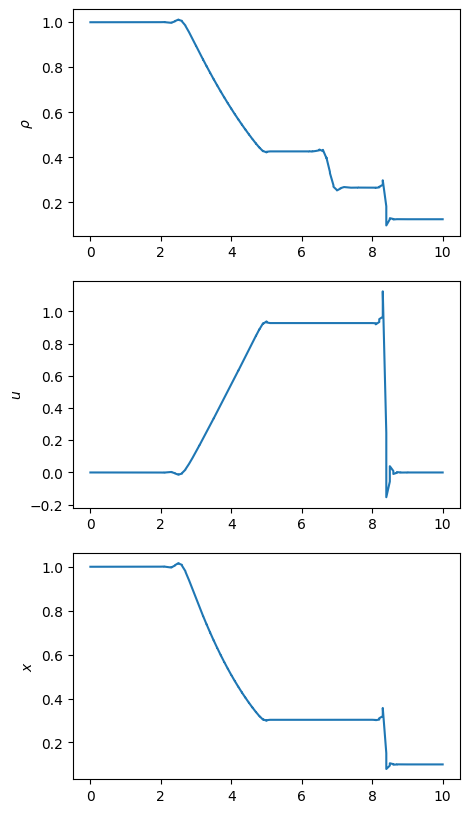

In [6]:
import numpy as np
import matplotlib.pylab as plt

class Nozzle:
    """
    1D Nozzle flow solver using DG method
    """
    def __init__(self, gamma=1.4, L=1.0, nelems=10, degree=1):

        self.gamma = gamma
        self.L = L
        self.nelems = nelems

        # Set the interpolation and quadrature properties
        if degree == 1:
            self.degree = 1
            self.nquad = 2 
            self.quad_pts = [-0.577350269189626, 0.577350269189626]
            self.quad_wts = [1.0, 1.0]
        else:
            self.degree = 2
            self.nquad = 3
            self.quad_pts = [-0.774596669241483, 0.0, 0.774596669241483]
            self.quad_wts = [5.0 / 9.0, 8.0 / 9.0, 5.0 / 9.0]

        # Set the scaling for the mapping between computational and physical coordinates
        self.scale = 0.5 * L / self.nelems
        self.inv_scale = 1.0 / self.scale

        # Initialize the mass matrix
        self._init_mass_matrix()

        return
        
    def eval_shape_funcs(self, xi):
        """Compute the shape functions at a quadrature point within the element"""
        N = np.zeros(self.degree + 1)
        Nx = np.zeros(self.degree + 1)

        if self.degree == 1:
            N[0] = 0.5 * (1.0 - xi)
            N[1] = 0.5 * (1.0 + xi)

            Nx[0] = -0.5 * self.inv_scale
            Nx[1] = 0.5 * self.inv_scale
        elif self.degree == 2:
            N[0] = 0.5 * xi * (xi - 1.0)
            N[1] = 1.0 - xi**2
            N[2] = 0.5 * xi * (1.0 + xi)

            Nx[0] = self.inv_scale * (xi - 0.5)
            Nx[1] = - 2.0 * self.inv_scale * xi
            Nx[2] = self.inv_scale * (xi + 0.5)

        return N, Nx

    def conv_flux(self, Q):
        rho = Q[0]
        u = Q[1] / rho
        E = Q[2] / rho
        p = (self.gamma - 1.0) * rho * (E - 0.5 * u**2)

        F = np.zeros(3, dtype=Q.dtype)
        F[0] = rho * u
        F[1] = rho * u**2 + p
        F[2] = u * (rho * E + p)

        return F
    
    def boundary_flux(self, Q):

        rho = Q[0]
        u = Q[1] / rho
        E = Q[2] / rho
        p = (self.gamma - 1.0) * rho * (E - 0.5 * u**2)

        F = np.zeros(3, dtype=Q.dtype)
        F[0] = 0.0
        F[1] = p
        F[2] = 0.0

        return F

    def source_flux(self, Q):
        S = np.zeros(3, dtype=Q.dtype)
        return S

    def roe_flux(self, QL, QR):
        F = np.zeros(3, dtype=QL.dtype)

        FL = self.conv_flux(QL)
        FR = self.conv_flux(QR)

        rhoL = QL[0]
        uL = QL[1] / rhoL
        EL = QL[2] / rhoL
        pL = (self.gamma - 1.0) * rhoL * (EL - 0.5 * uL**2)
        HL = (self.gamma / (self.gamma - 1.0)) * (pL / rhoL) + 0.5 * uL * uL

        rhoR = QR[0]
        uR = QR[1] / rhoR     
        ER = QR[2] / rhoR
        pR = (self.gamma - 1.0) * rhoR * (ER - 0.5 * uR**2)
        HR = (self.gamma / (self.gamma - 1.0)) * (pR / rhoR) + 0.5 * uR * uR

        r = np.sqrt(rhoR / rhoL)
        rho = r * rhoL
        u = (r * uR + uL) / (r + 1.0)
        H = (r * HR + HL) / (r + 1.0)

        a = np.sqrt((self.gamma - 1.0) * (H - 0.5 * u * u))

        w = np.zeros(3, dtype=QL.dtype)
        w[0] = ((rhoR - rhoL) - (pR - pL) / (a * a)) * np.fabs(u)
        w[1] = (0.5 * ((pR - pL) / (a * a) + (uR - uL) * (rho / a))) * np.fabs(u + a)
        w[2] = (0.5 * ((pR - pL) / (a * a) - (uR - uL) * (rho / a))) * np.fabs(u - a)

        F[0] = 0.5 * (FL[0] + FR[0]) - 0.5 * (w[0] + w[1] + w[2])
        F[1] = 0.5 * (FL[1] + FR[1]) - 0.5 * (w[0] * u + w[1] * (u + a) + w[2] * (u - a))
        F[2] = 0.5 * (FL[2] + FR[2]) - 0.5 * (0.5 * w[0] * u * u + w[1] * (H + u * a) + w[2] * (H - u * a))
        
        return F
    
    def _init_mass_matrix(self):
        M = np.zeros((self.nelems, self.degree + 1, self.degree + 1))

        for i in range(self.nelems):
            for j in range(self.nquad):
                N, Nx = self.eval_shape_funcs(self.quad_pts[j])
                M[i, :, :] += self.scale * self.quad_wts[j] * np.outer(N, N)

        for i in range(self.nelems):
            M[i, :, :] = np.linalg.inv(M[i, :, :])

        self.M = M
        return 
    
    def apply_mass_matrix_inverse(self, R):
        """Compute R = M^{-1} * R"""
        for i in range(self.nelems):
            for j in range(3):
                r = R[i * (self.degree + 1) : (i + 1) * (self.degree + 1), j]
                R[i * (self.degree + 1) : (i + 1) * (self.degree + 1), j] = self.M[i, :, :] @ r

        return
    
    def primitive_to_conservative(self, U):
        Q = np.zeros(U.shape, dtype=U.dtype)

        for i in range(U.shape[0]):
            Q[i, 0] = U[i, 0]
            Q[i, 1] = U[i, 0] * U[i, 1]
            Q[i, 2] = U[i, 2] / (self.gamma - 1.0) + 0.5 * U[i, 0] * U[i, 1] * U[i, 1]

        return Q

    def residual(self, Q):
        """
        Compute the residuals.
        """

        # Storage for the global residual
        R = np.zeros(((self.degree + 1) * self.nelems, 3), dtype=Q.dtype)

        # Storage for the local residual
        Re = np.zeros((self.degree + 1, 3), dtype=Q.dtype)

        for i in range(self.nelems):
            # Zero the local element contribution
            Re[:] = 0.0

            # Get the internal degrees of freedom for this element
            Qe = Q[i * (self.degree + 1) : (i + 1) * (self.degree + 1), :]

            for j in range(self.nquad):
                # Compute the shape functions for the given element
                N, Nx = self.eval_shape_funcs(self.quad_pts[j])

                # Interpolate to obtain the conservative variables at the quadrature point
                Qp = Qe.T @ N
                
                # Compute the convective flux and source fluxes
                Fp = self.conv_flux(Qp)
                Sp = self.source_flux(Qp)

                # Add the contributions to the local residual
                Re -= self.scale * self.quad_wts[j] * (np.outer(Nx, Fp) + np.outer(N, Sp))

            # Add the contributions to the residual
            R[i * (self.degree + 1) : (i + 1) * (self.degree + 1), :] += Re

        # Add the inter-element boundary terms
        for i in range(self.nelems - 1):
            # Extract the left and right states for the element interface
            QL = Q[(i + 1) * (self.degree + 1) - 1, :]
            QR = Q[(i + 1) * (self.degree + 1), :]

            # Compute the Roe Flux
            Fr = self.roe_flux(QL, QR)

            # Add the contribution to the residual
            R[(i + 1) * (self.degree + 1) - 1, :] += Fr
            R[(i + 1) * (self.degree + 1), :] -= Fr

        # Add the boundary conditions - reflective on both sides
        QL = Q[0, :]
        FL = self.boundary_flux(QL)
        R[0, :] -= FL

        QR = Q[-1, :]
        FR = self.boundary_flux(QR)
        R[-1, :] += FR

        return R

    def iterate(self, Q, dt=1e-3, iters=100):
        for i in range(iters):
            R = self.residual(Q)
            self.apply_mass_matrix_inverse(R)
            Q -= dt * R

        return Q

# The length of the shock tube
length = 10.0 # m

# The initial conditions
pL = 1e5      # Pa
rhoL = 1.0    # kg / m^3
pR = 1e4      # Pa
rhoR = 0.125  # kg / m^3
T0 = 1000.0   # Reference temperature

# Final time
final_time = 6.1e-3  # 6.1 ms

# Set reference values and fluid properties
gamma = 1.4
rho_ref = rhoL
gas_const = 287.015
T_ref = pL / (1.4 * gas_const * rho_ref)
sound_speed_ref = np.sqrt(gamma * gas_const * T_ref)
pressure_ref = rho_ref * sound_speed_ref * sound_speed_ref

num_steps = 2440
dt = sound_speed_ref * (final_time / num_steps)

# Create the nozzle problem
nozzle = Nozzle(gamma=gamma, L=length, nelems=100, degree=1)

# Set the initial conditions
nstates = nozzle.nelems * (nozzle.degree + 1)
mid = (nozzle.nelems // 2) * (nozzle.degree + 1)

U = np.zeros((nstates, 3))
U[:mid, 0] = rhoL / rho_ref
U[:mid, 2] = pL / pressure_ref
U[mid:, 0] = rhoR / rho_ref
U[mid:, 2] = pR / pressure_ref

# Convert to primitive variables
Q = nozzle.primitive_to_conservative(U)

# Iterate until the end
Q = nozzle.iterate(Q, dt=dt, iters=num_steps)
nelems = nozzle.nelems
degree = nozzle.degree

x = np.zeros((degree + 1) * nelems)
for i in range(nelems):
    x[i * (degree + 1) : (i + 1) * (degree + 1)] = i * length / nelems + np.linspace(0, length / nelems, degree + 1)

p = (gamma - 1.0) * (Q[:, 2] - 0.5 * Q[:, 1]**2 / Q[:, 0])
fig, ax = plt.subplots(3, 1, figsize=(5, 10))
ax[0].plot(x, Q[:, 0])
ax[1].plot(x, Q[:, 1] / Q[:, 0])
ax[2].plot(x, p)
ax[0].set_ylabel(r"$\rho$")
ax[1].set_ylabel(r"$u$")
ax[2].set_ylabel(r"$p$")
ax[2].set_ylabel(r"$x$")
plt.show()
